1. Import Libraries

In [6]:
import pandas as pd
import re
import nltk
import matplotlib.pyplot as plt

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB

from sklearn.metrics import accuracy_score, classification_report
from wordcloud import WordCloud

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

2. Create Banking Complaint Dataset

In [7]:
data = {
    "Complaint": [
        "My online banking account is not working.",
        "Money was deducted from my account but the transaction failed.",
        "I am unable to withdraw money from the ATM.",
        "My loan application has been rejected without explanation.",
        "The bank charged me extra transaction fees.",
        "I cannot access my mobile banking application.",
        "My account balance is showing the wrong amount.",
        "The loan approval process is taking too long.",
        "I did not receive the money after making a transfer.",
        "My debit card was blocked suddenly.",
        "There is an unknown transaction in my account.",
        "The bank has not processed my loan yet.",
        "Online payment failed but money was deducted.",
        "I forgot my banking password and cannot login.",
        "The bank charged a high interest rate on my loan.",
        "My account statement contains incorrect information.",
        "ATM did not dispense cash but money was deducted.",
        "The mobile banking app keeps crashing.",
        "I want to know why my transaction failed.",
        "My loan repayment amount is incorrect."
    ],

    "Category": [
        "Online Banking",
        "Transaction",
        "ATM",
        "Loan",
        "Transaction",
        "Online Banking",
        "Account Management",
        "Loan",
        "Transaction",
        "ATM",
        "Transaction",
        "Loan",
        "Transaction",
        "Online Banking",
        "Loan",
        "Account Management",
        "ATM",
        "Online Banking",
        "Transaction",
        "Loan"
    ]
}

In [8]:
df = pd.DataFrame(data)
print(df.head())

                                           Complaint        Category
0          My online banking account is not working.  Online Banking
1  Money was deducted from my account but the tra...     Transaction
2        I am unable to withdraw money from the ATM.             ATM
3  My loan application has been rejected without ...            Loan
4        The bank charged me extra transaction fees.     Transaction


3. Preprocess Complaint Text

In [9]:
stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

def clean_text(text):
    text = text.lower()
    text = re.sub(r"[^a-zA-Z\s]", "", text)
    words = word_tokenize(text)
    words = [word for word in words if word not in stop_words]
    words = [lemmatizer.lemmatize(word) for word in words]
    return " ".join(words)

In [10]:
df["Clean_Complaint"] = df["Complaint"].apply(clean_text)
print(df[["Complaint", "Clean_Complaint"]].head())

                                           Complaint  \
0          My online banking account is not working.   
1  Money was deducted from my account but the tra...   
2        I am unable to withdraw money from the ATM.   
3  My loan application has been rejected without ...   
4        The bank charged me extra transaction fees.   

                                 Clean_Complaint  
0                 online banking account working  
1      money deducted account transaction failed  
2                      unable withdraw money atm  
3  loan application rejected without explanation  
4             bank charged extra transaction fee  


4. Convert Text into TF-IDF

In [11]:
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(df["Clean_Complaint"])
y = df["Category"]

5. Split Dataset

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

6. Train Classification Model

In [13]:
model = MultinomialNB()
model.fit(X_train, y_train)

MultinomialNB()

7. Categorize Complaints

In [14]:
y_pred = model.predict(X_test)

print("Predicted Categories:")
print(y_pred)

Predicted Categories:
['Transaction' 'Transaction' 'Loan' 'Transaction']


In [15]:
new_complaint = [
    "I cannot login to my mobile banking application."
]

new_complaint = [clean_text(text) for text in new_complaint]
new_vector = vectorizer.transform(new_complaint)
prediction = model.predict(new_vector)
print("Complaint Category:", prediction[0])

Complaint Category: Online Banking


8. Evaluate the Model

In [16]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.25

Classification Report:
                    precision    recall  f1-score   support

Account Management       0.00      0.00      0.00         1
              Loan       0.00      0.00      0.00         0
    Online Banking       0.00      0.00      0.00         2
       Transaction       0.33      1.00      0.50         1

          accuracy                           0.25         4
         macro avg       0.08      0.25      0.12         4
      weighted avg       0.08      0.25      0.12         4



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_

9. Identify Frequent Banking Issues

In [17]:
print(df["Category"].value_counts())

Category
Transaction           6
Loan                  5
Online Banking        4
ATM                   3
Account Management    2
Name: count, dtype: int64


Graph

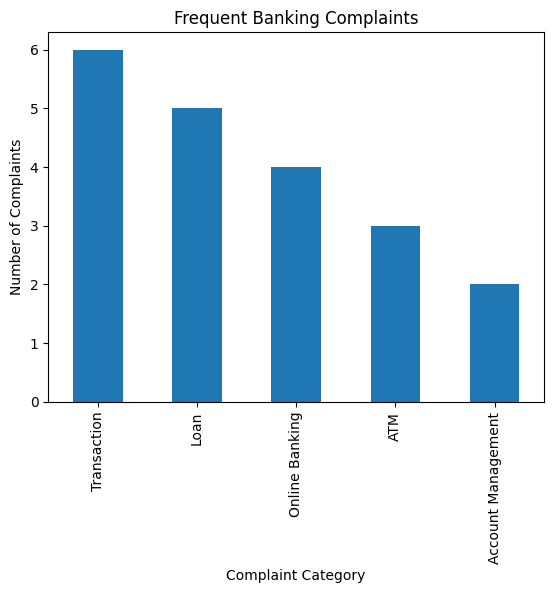

In [18]:
df["Category"].value_counts().plot(kind="bar")

plt.title("Frequent Banking Complaints")
plt.xlabel("Complaint Category")
plt.ylabel("Number of Complaints")
plt.show()

10. Word Cloud

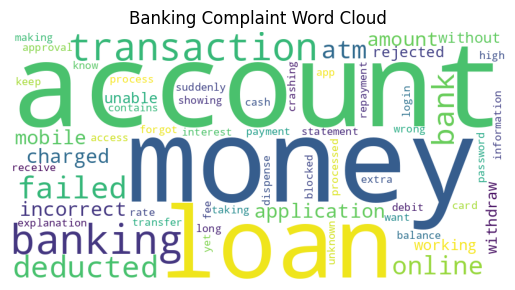

In [19]:
all_words = " ".join(df["Clean_Complaint"])

wordcloud = WordCloud(
    width=800,
    height=400,
    background_color="white"
).generate(all_words)

plt.imshow(wordcloud)
plt.axis("off")
plt.title("Banking Complaint Word Cloud")
plt.show()

11. Analytical Report

In [20]:
print("BANKING COMPLAINT ANALYTICAL REPORT")
print("------------------------------------")

print("Total Complaints:", len(df))

print("\nComplaint Categories:")
print(df["Category"].value_counts())

most_common = df["Category"].value_counts().idxmax()

print("\nMost Frequent Issue:", most_common)

print("\nConclusion:")
print("The bank can use complaint categories to identify common")
print("customer problems and improve customer support services.")

BANKING COMPLAINT ANALYTICAL REPORT
------------------------------------
Total Complaints: 20

Complaint Categories:
Category
Transaction           6
Loan                  5
Online Banking        4
ATM                   3
Account Management    2
Name: count, dtype: int64

Most Frequent Issue: Transaction

Conclusion:
The bank can use complaint categories to identify common
customer problems and improve customer support services.
